In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
x,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

1. n_samples=4

Specifies the number of data points (rows) to generate.

2. n_features=1

Specifies the number of input features (columns).

n_features = 1

Means there is only one independent variable.

3. n_informative=1

This is one of the most misunderstood parameters.

It tells make_regression:

How many of the generated features actually influence the target (y).

Suppose :-

n_features=5

and

n_informative=2

Then

Feature	Useful?
X1	✅
X2	✅
X3	❌ Noise
X4	❌ Noise
X5	❌ Noise

Only two features determine the target.

The remaining features are random and contain no predictive information.

4. n_targets=1

Specifies the number of output variables.

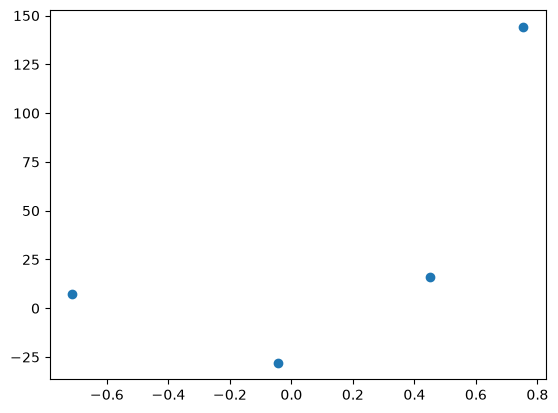

In [3]:
import matplotlib.pyplot as plt

plt.scatter(x,y)

In [4]:
# lets find value of m
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[78.35]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.11]


In [5]:
m=model.coef_ # slope = m

In [6]:
model.intercept_  # y_intercept = b

np.float64(26.15963284313262)

In [7]:
y_predicted=model.predict(x)

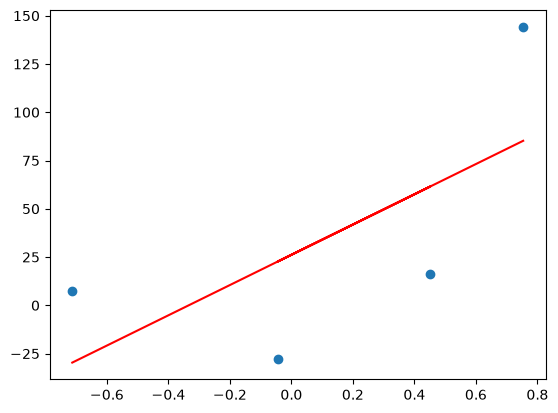

In [8]:
plt.scatter(x,y)
plt.plot(x,y_predicted,color="red")

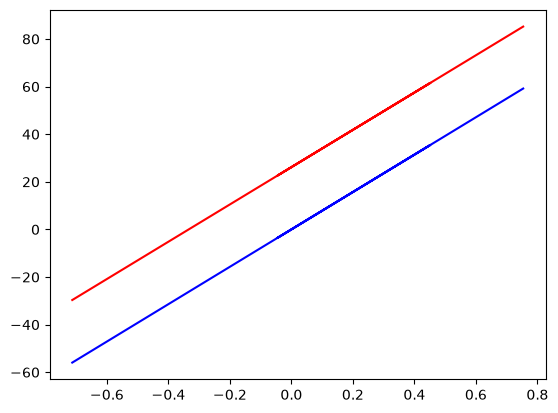

In [9]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0

m=78.53
b=0
y_pred = ((m * x) +b ).reshape(4)
plt.plot(x,model.predict(x),color="red")
plt.plot(x,y_pred,color="blue")

-7.853000000000001


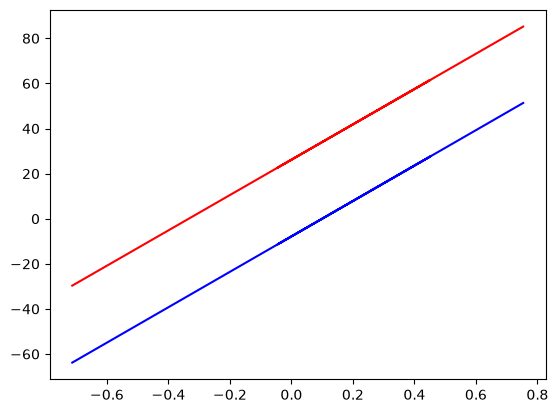

In [10]:

# let learning rate=0.1
lr=0.1
m=78.53
b=b-lr*m
print(b)
y_pred = ((m * x) +b ).reshape(4)
plt.plot(x,model.predict(x),color="red")
plt.plot(x,y_pred,color="blue")

-15.706000000000001


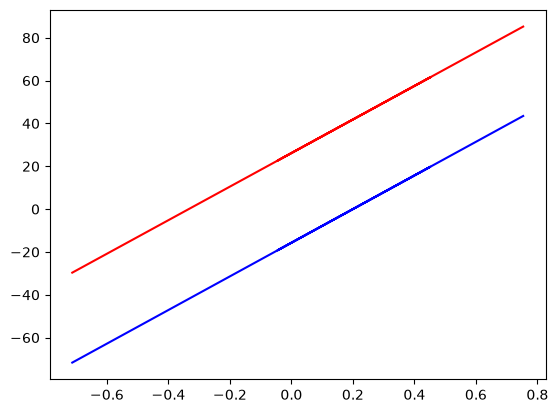

In [11]:
# let learning rate=0.1
lr=0.1
m=78.53
b=b-lr*m
print(b)
y_pred = ((m * x) +b ).reshape(4)
plt.plot(x,model.predict(x),color="red")
plt.plot(x,y_pred,color="blue")

-23.559


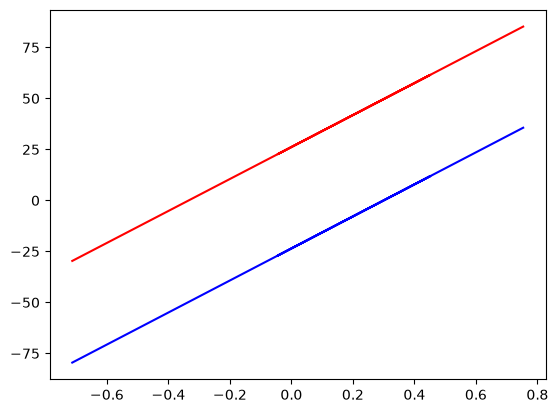

In [12]:
lr=0.1
m=78.53
b=b-lr*m
print(b)
y_pred = ((m * x) +b ).reshape(4)
plt.plot(x,model.predict(x),color="red")
plt.plot(x,y_pred,color="blue")

40.91161074903661
29.093932898843928
26.73039732880539
26.257690214797687
26.163148791996147
26.144240507435835
26.140458850523775
26.139702519141363


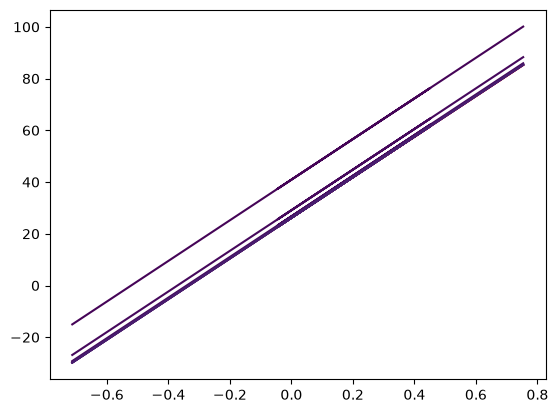

In [13]:
b_old = 0
b_new = 100     
colors = plt.cm.viridis(np.linspace(0, 1, 100))
plt.plot(x, model.predict(x), color="red")
i=1
lr = 0.1
m = 78.53

while abs(b_old - b_new) > 0.001:

    b_old = b_new

    gradient = -2 * np.sum(y - (m*x.ravel() + b_old))

    b_new = b_old - lr * gradient

    print(b_new)

    y_pred = m*x + b_new
    if(i==100):
         i=0
    plt.plot(x, y_pred, color=colors[i])
    i=i+1

m,b ----> NOT KNOWN

In [14]:
class GDReg:
    def __init__(self,lr,epochs):
        self.m=10
        self.b=0
        self.learning_rate=lr
        self.epochs=epochs
    

    def fit(self,x,y):
        for i in range(self.epochs):
            gradient_b=-2*(y-self.m*x.ravel()-self.b)
            gradient_m=-2*(y-self.m*x.ravel()-self.b)*x.ravel()

            self.b=self.b-self.learning_rate*gradient_b
            self.m=self.m-self.learning_rate*gradient_m



In [15]:
gd=GDReg(lr=0.05,epochs=1000)
gd.fit(x,y)